In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [210]:
data = pd.read_csv('weather_test.csv')
data.head(15)

,timestamp,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,rainfall_mm,weather
0,2018-01-01 00:00:00,18.1,70.0,1023.9,NaN,0.00,Rainy
1,2018-01-01 01:00:00,21.8,66.0,1015.8,13.1,0.71,Cloudy
2,2018-01-01 02:00:00,31.7,69.0,1016.4,5.1,0.69,Foggy
3,2018-01-01 03:00:00,25.2,88.0,1016.9,20.5,3.57,Sunny
4,2018-01-01 04:00:00,29.5,NaN,1018.5,NaN,0.10,NaN
5,2018-01-01 05:00:00,27.5,64.0,1015.9,1.5,0.00,Foggy
6,2018-01-01 06:00:00,20.2,68.0,1020.7,9.2,0.64,Cloudy
7,2018-01-01 07:00:00,27.3,83.0,1010.7,2.4,0.00,NaN
8,2018-01-01 08:00:00,22.1,99.0,1022.2,14.8,0.34,Stormy
9,2018-01-01 09:00:00,22.1,60.0,1013.1,1.4,0.02,Sunny


In [211]:
data['timestamp'] = pd.to_datetime(data['timestamp'],
                                   utc=True)
data['year'] = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month
data['day'] = data['timestamp'].dt.day

data.head(5)


,timestamp,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,rainfall_mm,weather,year,month,day
0,2018-01-01 00:00:00+00:00,18.1,70.0,1023.9,NaN,0.00,Rainy,2018,1,1
1,2018-01-01 01:00:00+00:00,21.8,66.0,1015.8,13.1,0.71,Cloudy,2018,1,1
2,2018-01-01 02:00:00+00:00,31.7,69.0,1016.4,5.1,0.69,Foggy,2018,1,1
3,2018-01-01 03:00:00+00:00,25.2,88.0,1016.9,20.5,3.57,Sunny,2018,1,1
4,2018-01-01 04:00:00+00:00,29.5,NaN,1018.5,NaN,0.10,NaN,2018,1,1


<Axes: >

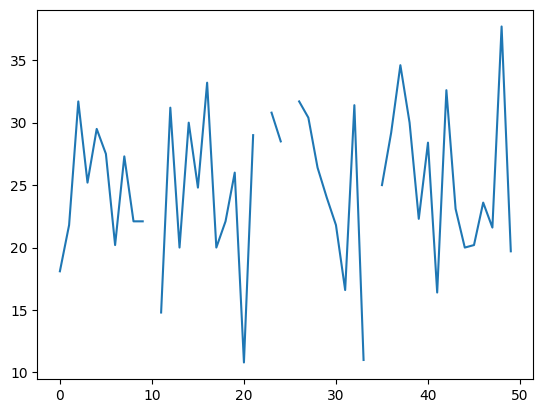

In [212]:
data['temperature_c'].head(50).plot()

<Axes: >

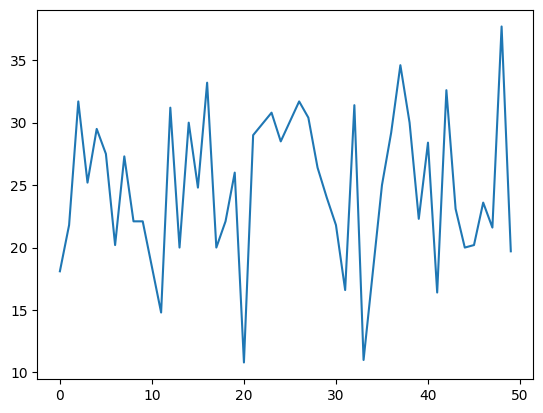

In [213]:
data['temperature_c'].interpolate(method='linear', limit_direction='forward').head(50).plot()

<Axes: >

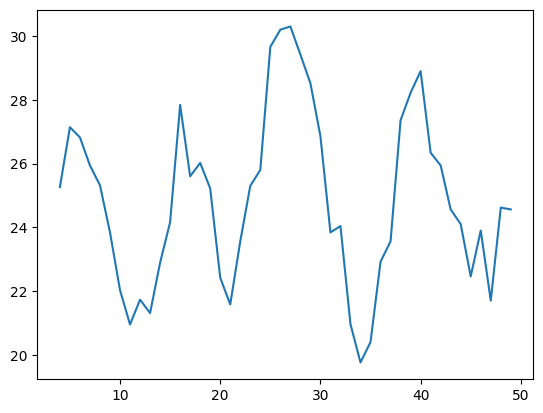

In [214]:
data['temperature_c'].interpolate().rolling(window=5).mean().head(50).plot()

In [215]:
data['name'] = 'abc'
data.head(5)
data.drop('name', axis=1)
data.drop([1, 2, 3])
data.drop(['humidity_pct', 'rainfall_mm'], axis=1)

,timestamp,temperature_c,pressure_hpa,wind_speed_kmh,weather,year,month,day,name
0,2018-01-01 00:00:00+00:00,18.1,1023.9,NaN,Rainy,2018,1,1,abc
1,2018-01-01 01:00:00+00:00,21.8,1015.8,13.1,Cloudy,2018,1,1,abc
2,2018-01-01 02:00:00+00:00,31.7,1016.4,5.1,Foggy,2018,1,1,abc
3,2018-01-01 03:00:00+00:00,25.2,1016.9,20.5,Sunny,2018,1,1,abc
4,2018-01-01 04:00:00+00:00,29.5,1018.5,NaN,NaN,2018,1,1,abc
...,...,...,...,...,...,...,...,...,...
69995,2025-12-26 11:00:00+00:00,20.4,1031.9,7.8,NaN,2025,12,26,abc
69996,2025-12-26 12:00:00+00:00,25.4,1020.1,11.0,Rainy,2025,12,26,abc
69997,2025-12-26 13:00:00+00:00,30.7,NaN,18.2,Foggy,2025,12,26,abc
69998,2025-12-26 14:00:00+00:00,26.1,1013.9,10.4,Rainy,2025,12,26,abc


In [216]:
data.describe()

,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,rainfall_mm,year,month,day
count,64540.000000,64366.000000,64341.000000,64356.000000,64336.000000,70000.000000,70000.000000,70000.000000
mean,24.018424,69.852003,1012.957509,12.141713,0.616036,2021.493943,6.512914,15.705714
std,5.999578,14.665905,8.007828,5.782629,1.046811,2.288351,3.443910,8.790130
min,-2.500000,20.000000,976.200000,0.000000,0.000000,2018.000000,1.000000,1.000000
25%,20.000000,60.000000,1007.600000,8.000000,0.000000,2019.000000,4.000000,8.000000
50%,24.000000,70.000000,1013.000000,12.100000,0.040000,2021.000000,7.000000,16.000000
75%,28.100000,80.000000,1018.400000,16.100000,0.870000,2023.000000,10.000000,23.000000
max,50.400000,100.000000,1049.300000,36.900000,12.370000,2025.000000,12.000000,31.000000


In [217]:
data.loc[(data.temperature_c < 20) & (data.humidity_pct > 50)]
# data.loc[data['temperature_c'] < 20]

,timestamp,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,rainfall_mm,weather,year,month,day,name
0,2018-01-01 00:00:00+00:00,18.1,70.0,1023.9,NaN,0.00,Rainy,2018,1,1,abc
31,2018-01-02 07:00:00+00:00,16.6,64.0,1008.9,NaN,0.00,Cloudy,2018,1,2,abc
33,2018-01-02 09:00:00+00:00,11.0,60.0,1036.5,14.6,NaN,Cloudy,2018,1,2,abc
41,2018-01-02 17:00:00+00:00,16.4,77.0,1014.1,9.7,NaN,Sunny,2018,1,2,abc
49,2018-01-03 01:00:00+00:00,19.7,100.0,1000.2,16.2,0.24,Cloudy,2018,1,3,abc
...,...,...,...,...,...,...,...,...,...,...,...
69977,2025-12-25 17:00:00+00:00,18.4,82.0,1013.7,17.4,0.00,Foggy,2025,12,25,abc
69980,2025-12-25 20:00:00+00:00,18.8,90.0,1008.0,1.2,0.42,Rainy,2025,12,25,abc
69986,2025-12-26 02:00:00+00:00,18.7,73.0,1019.5,9.4,0.74,Cloudy,2025,12,26,abc
69988,2025-12-26 04:00:00+00:00,15.4,86.0,1019.3,18.3,0.00,Sunny,2025,12,26,abc


In [218]:
data.info()
data['weather'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   timestamp       70000 non-null  datetime64[us, UTC]
 1   temperature_c   64540 non-null  float64            
 2   humidity_pct    64366 non-null  float64            
 3   pressure_hpa    64341 non-null  float64            
 4   wind_speed_kmh  64356 non-null  float64            
 5   rainfall_mm     64336 non-null  float64            
 6   weather         64273 non-null  str                
 7   year            70000 non-null  int32              
 8   month           70000 non-null  int32              
 9   day             70000 non-null  int32              
 10  name            70000 non-null  str                
dtypes: datetime64[us, UTC](1), float64(5), int32(3), str(2)
memory usage: 5.1 MB


weather
Sunny     22604
Cloudy    19424
Rainy     12784
Foggy      6325
Stormy     3136
Name: count, dtype: int64

In [219]:
import seaborn as sns

In [220]:
numeric_cols = data.select_dtypes(include='number').columns

data[numeric_cols] = data[numeric_cols].interpolate(method='linear', limit_direction='both')
data.head(15)

,timestamp,temperature_c,humidity_pct,pressure_hpa,wind_speed_kmh,rainfall_mm,weather,year,month,day,name
0,2018-01-01 00:00:00+00:00,18.10,70.0,1023.9,13.1,0.00,Rainy,2018,1,1,abc
1,2018-01-01 01:00:00+00:00,21.80,66.0,1015.8,13.1,0.71,Cloudy,2018,1,1,abc
2,2018-01-01 02:00:00+00:00,31.70,69.0,1016.4,5.1,0.69,Foggy,2018,1,1,abc
3,2018-01-01 03:00:00+00:00,25.20,88.0,1016.9,20.5,3.57,Sunny,2018,1,1,abc
4,2018-01-01 04:00:00+00:00,29.50,76.0,1018.5,11.0,0.10,NaN,2018,1,1,abc
5,2018-01-01 05:00:00+00:00,27.50,64.0,1015.9,1.5,0.00,Foggy,2018,1,1,abc
6,2018-01-01 06:00:00+00:00,20.20,68.0,1020.7,9.2,0.64,Cloudy,2018,1,1,abc
7,2018-01-01 07:00:00+00:00,27.30,83.0,1010.7,2.4,0.00,NaN,2018,1,1,abc
8,2018-01-01 08:00:00+00:00,22.10,99.0,1022.2,14.8,0.34,Stormy,2018,1,1,abc
9,2018-01-01 09:00:00+00:00,22.10,60.0,1013.1,1.4,0.02,Sunny,2018,1,1,abc


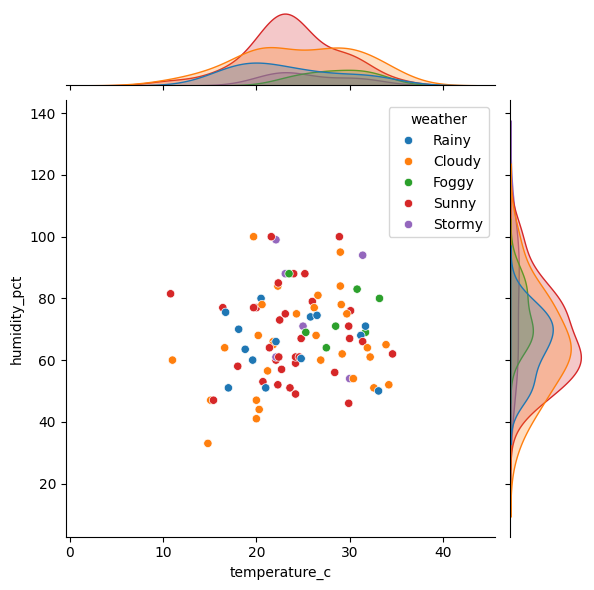

In [221]:
sns.jointplot(
    x='temperature_c',
    y='humidity_pct',
    data=data[:100],
    hue='weather'
)
plt.show()